In [1]:
import matplotlib.pyplot as plt
from plot_functions import plot_te_carbon_frontiers_all_periods, plot_te_carbon_by_sector

Figure saved to: results/te_carbon_frontiers_all_periods.pdf


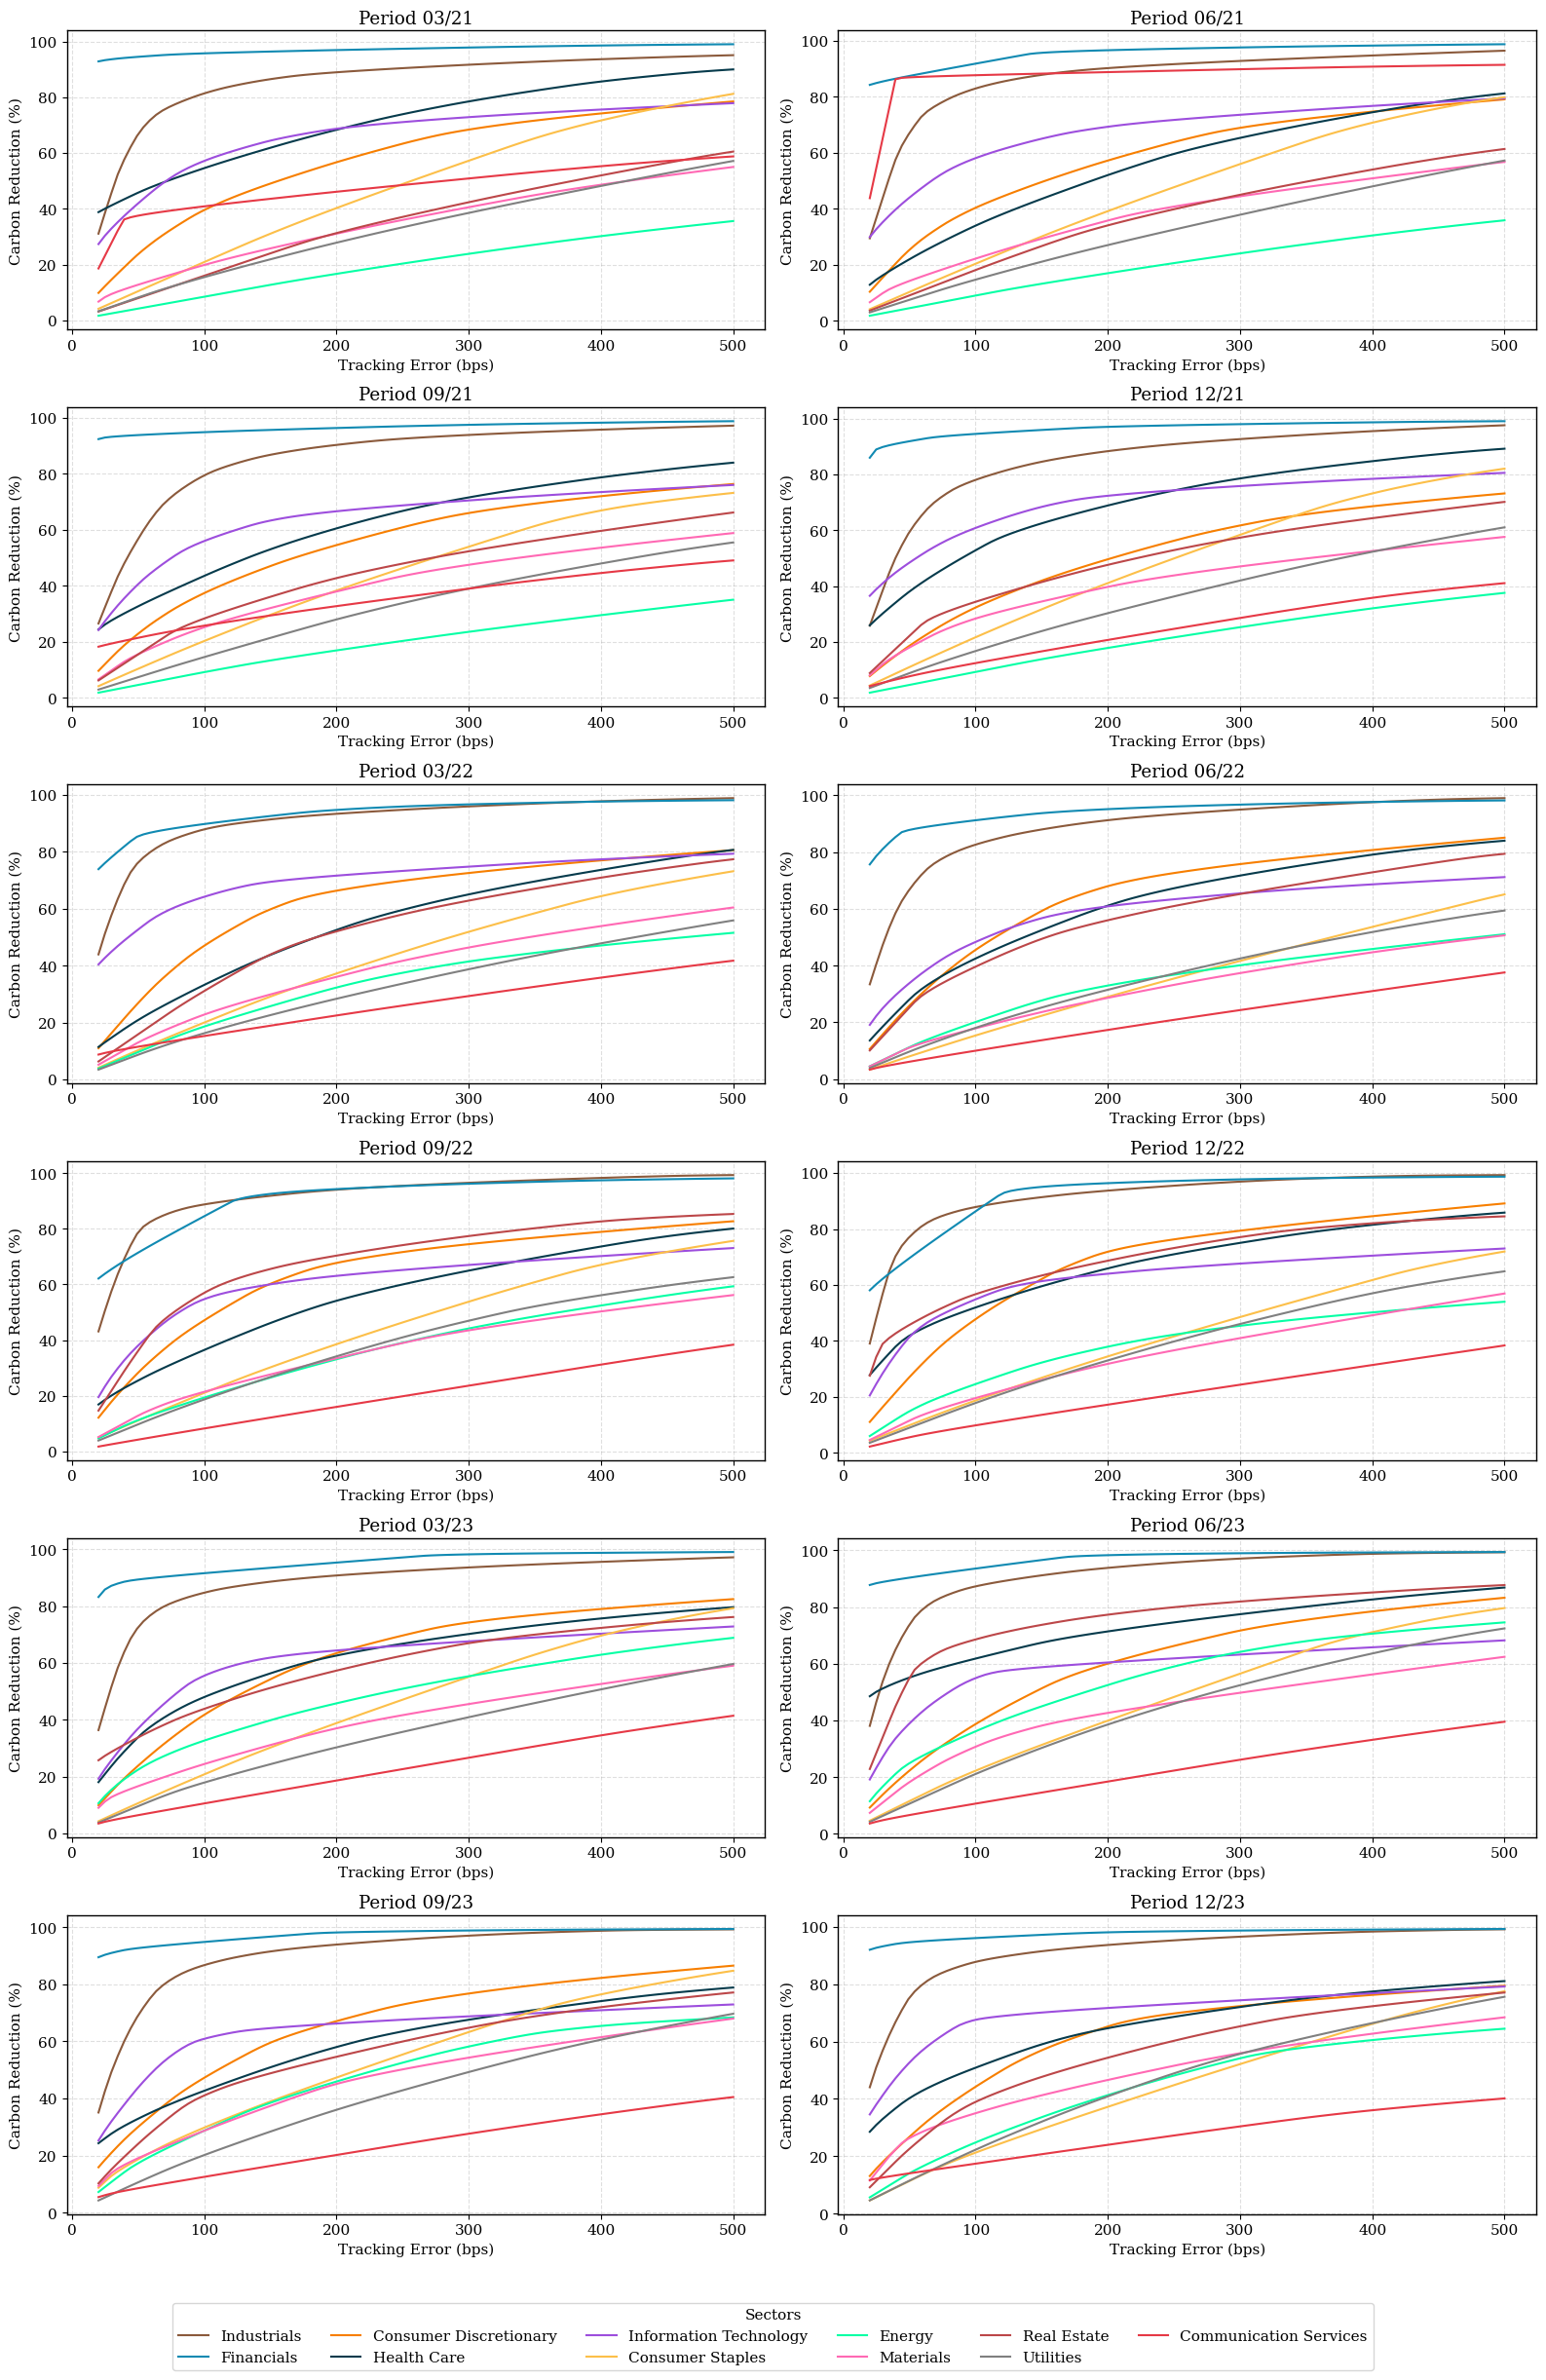

In [2]:
# Plot and save TE-Carbon frontiers for all periods
fig = plot_te_carbon_frontiers_all_periods(
    portfolio_dir="results/optimal_portfolios/",
    output_path="results/te_carbon_frontiers_all_periods.pdf"
)
plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os


def plot_te_carbon_by_sector_simple(
    tracking_errors,
    carbon_reductions,
    tracking_errors_np,
    absolute_te_points,
    sector_name,
    relative_te_points,
    save_plot=True,
    show_plot=False,
    fig_dir="figures/te_carbon",
    tag="raw"
):
    """
    Cleaner, self-contained version of the TE–carbon frontier plotter.
    Returns the full list of relative deltas rather than modifying external dicts.
    """

    relative_deltas = []   # we return this now

    # Prepare figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -------------------------
    # LEFT PLOT: ABSOLUTE CHANGE
    # -------------------------
    ax1 = axes[0]
    ax1.plot(tracking_errors, carbon_reductions, 'x-', label=f'{tag} frontier')

    x_base, y_base = tracking_errors[0], carbon_reductions[0]

    for te_target in absolute_te_points:
        idx_target = np.argmin(np.abs(tracking_errors_np - te_target))
        x_target = tracking_errors[idx_target]
        y_target = carbon_reductions[idx_target]

        # arrow
        ax1.annotate('', xy=(x_target, y_target), xytext=(x_base, y_base),
                     arrowprops=dict(arrowstyle='->', lw=1.2, color='#888888'))

        abs_delta = y_target - y_base

        # text half-way
        ax1.text(
            (x_base + x_target) / 2,
            (y_base + y_target) / 2,
            f'{abs_delta:.1f}%',
            fontsize=8,
            color="#444444",
            ha='center'
        )

    ax1.set_title(f'{sector_name} – Absolute Change [{tag}]')
    ax1.set_xlabel('Tracking Error (bps)')
    ax1.set_ylabel('Carbon Reduction (%)')
    ax1.grid(True)

    # -------------------------
    # RIGHT PLOT: RELATIVE CHANGE
    # -------------------------
    ax2 = axes[1]
    ax2.plot(tracking_errors, carbon_reductions, 'x-', alpha=0.3)

    base_y = min(carbon_reductions)
    step_height = 0.8

    for i in range(len(relative_te_points) - 1):

        te_start = relative_te_points[i]
        te_end = relative_te_points[i + 1]

        idx_start = np.argmin(np.abs(tracking_errors_np - te_start))
        idx_end = np.argmin(np.abs(tracking_errors_np - te_end))

        x_start = tracking_errors[idx_start]
        x_end = tracking_errors[idx_end]

        y1 = carbon_reductions[idx_start]
        y2 = carbon_reductions[idx_end]

        # relative change
        rel_delta = (y2 - y1) / y1 * 100 if y1 != 0 else np.nan
        relative_deltas.append(rel_delta)

        # arrow y-level
        y_arrow = base_y + i * step_height

        ax2.annotate('', xy=(x_end, y_arrow), xytext=(x_start, y_arrow),
                     arrowprops=dict(arrowstyle='->', lw=1.2, color='green'))

        ax2.text(
            (x_start + x_end) / 2,
            y_arrow + 0.15,
            f'{rel_delta:.1f}%',
            fontsize=7,
            color='green',
            ha='center'
        )

    ax2.set_title(f'{sector_name} – Relative Change [{tag}]')
    ax2.set_xlabel('Tracking Error (bps)')
    ax2.set_ylabel('Carbon Reduction (%)')
    ax2.grid(True)

    plt.tight_layout()

    # save
    if save_plot:
        os.makedirs(fig_dir, exist_ok=True)
        fname = f"{sector_name.replace(' ', '_')}_te_carbon_{tag}.png"
        fpath = os.path.join(fig_dir, fname)
        plt.savefig(fpath, dpi=300, bbox_inches="tight")
        print(f"📈 Saved: {fpath}")

    if show_plot:
        plt.show()
    else:
        plt.close()

    return relative_deltas


📈 Saved: figures/te_carbon/Industrials_te_carbon_last_period.png


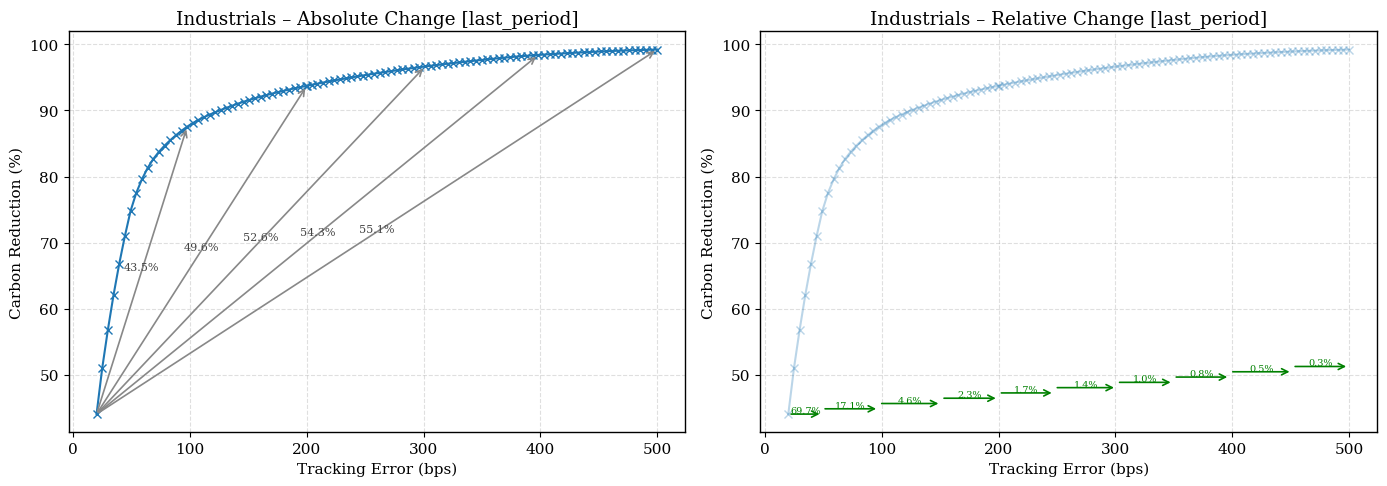

📈 Saved: figures/te_carbon/Financials_te_carbon_last_period.png


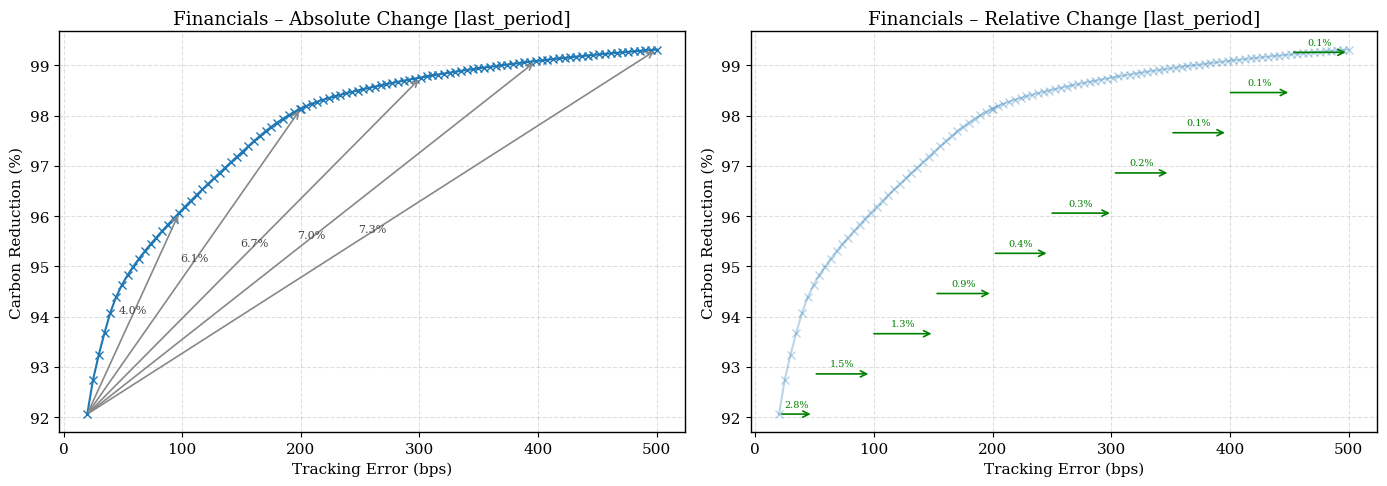

📈 Saved: figures/te_carbon/Real_Estate_te_carbon_last_period.png


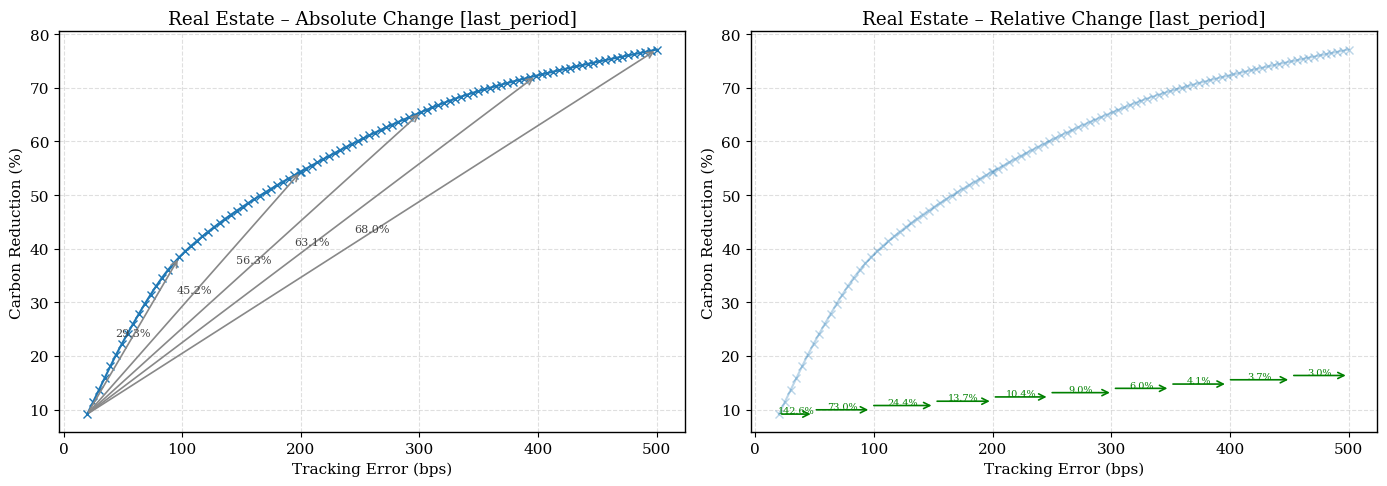


=== Relative Deltas (last period) ===
Industrials → [69.66921958628136, 17.067751483662455, 4.61845254422422, 2.330792457628015, 1.6585260706749008, 1.4313574217323697, 1.020620233215607, 0.7769647455448374, 0.5326561515327609, 0.2956117557582215]
Financials → [2.7871166929071824, 1.5279834688981258, 1.263613923168899, 0.8780247082065281, 0.3673653819986295, 0.2627461349898353, 0.18375014782360566, 0.14692687228455217, 0.1336641122630396, 0.09758822417898107]
Real Estate → [142.61548796081297, 72.9500691676595, 24.419084682473063, 13.743876502785914, 10.417441030881234, 8.985248157355379, 6.0155666549312485, 4.130380535134394, 3.6989154645326665, 2.953137819757814]


In [4]:
from pathlib import Path
import pickle
import numpy as np

# Load last available period
last_pickle = sorted(Path("results/optimal_portfolios").glob("optimal_portfolios_all_te_*.pkl"))[-1]
with open(last_pickle, "rb") as f:
    sector_data = pickle.load(f)

target_sectors = ["Industrials", "Financials", "Real Estate"]

absolute_te_points = [100, 200, 300, 400, 500]
relative_te_points = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

sector_relative_deltas = {}

for sec in target_sectors:
    data = sector_data[sec]

    tracking_errors = np.array(data["tracking_errors"])
    carbon_reductions = np.array(data["carbon_reductions"])
    tracking_errors_np = tracking_errors.copy()

    rel = plot_te_carbon_by_sector_simple(
        tracking_errors=tracking_errors,
        carbon_reductions=carbon_reductions,
        tracking_errors_np=tracking_errors_np,
        absolute_te_points=absolute_te_points,
        sector_name=sec,
        relative_te_points=relative_te_points,
        tag="last_period",
        show_plot=True
    )

    sector_relative_deltas[sec] = rel

print("\n=== Relative Deltas (last period) ===")
for sec, arr in sector_relative_deltas.items():
    print(sec, "→", arr)


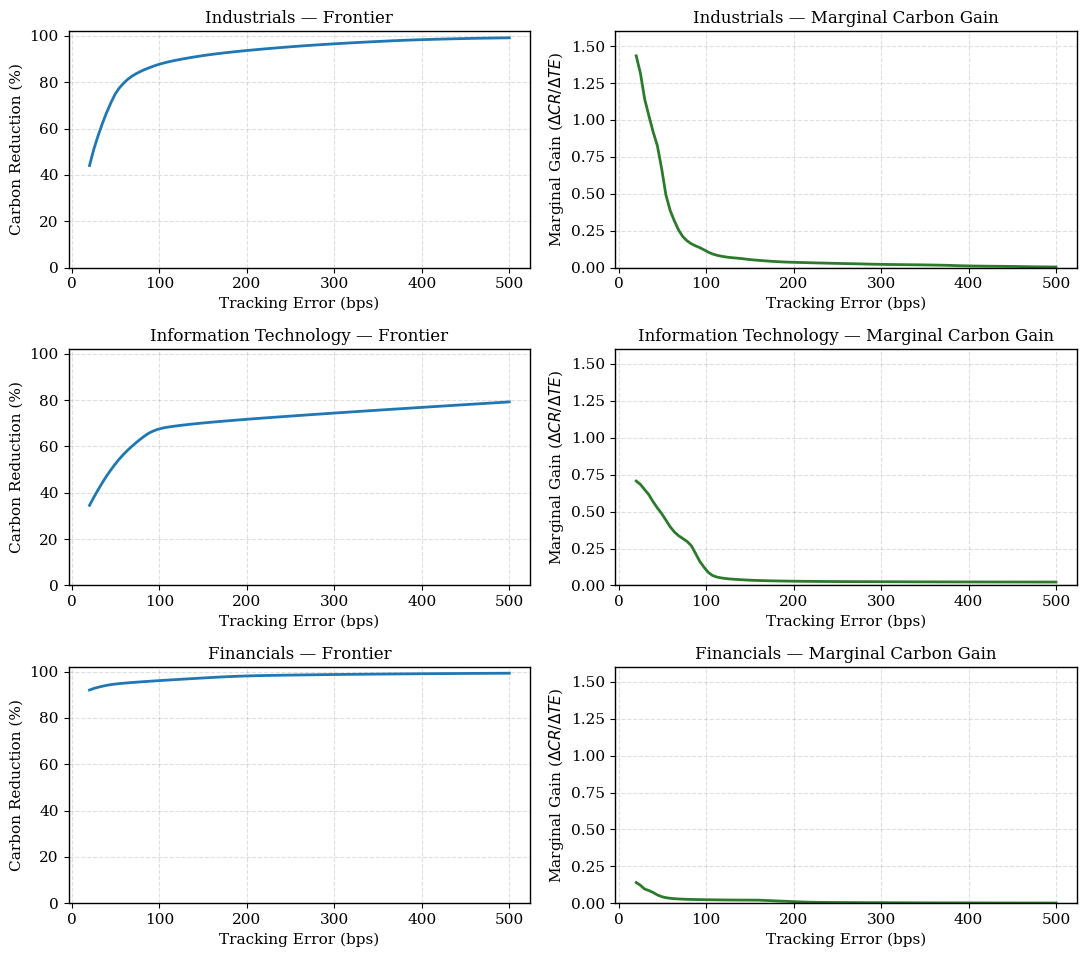

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle

# -----------------------
# GLOBAL ACADEMIC STYLE
# -----------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "gray",
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# Load latest period
last_pickle = sorted(Path("results/optimal_portfolios").glob("optimal_portfolios_all_te_*.pkl"))[-1]

with open(last_pickle, "rb") as f:
    last_period = pickle.load(f)

sectors_to_plot = ["Industrials", "Information Technology", "Financials"]

fig, axes = plt.subplots(3, 2, figsize=(11, 10))

for row, sector in enumerate(sectors_to_plot):

    data = last_period[sector]
    te = np.array(data["tracking_errors"])
    cr = np.array(data["carbon_reductions"])

    # -----------------------
    # 1) Frontier
    # -----------------------
    ax_frontier = axes[row, 0]
    ax_frontier.plot(te, cr, "-", lw=2.0, color="#1f77b4")
    ax_frontier.set_title(f"{sector} — Frontier", fontsize=12)
    ax_frontier.set_xlabel("Tracking Error (bps)")
    ax_frontier.set_ylabel("Carbon Reduction (%)")
    ax_frontier.set_ylim(0, 102)   # instead of (0, 100)

    ax_frontier.grid(True)

    # -----------------------
    # 2) Marginal gains
    # -----------------------
    marginal = np.gradient(cr, te)
    ax_marg = axes[row, 1]
    ax_marg.plot(te, marginal, "-", lw=2.0, color="#2c7a2c")
    ax_marg.axhline(0, color="black", linewidth=0.8)
    ax_marg.set_title(f"{sector} — Marginal Carbon Gain", fontsize=12)
    ax_marg.set_xlabel("Tracking Error (bps)")
    ax_marg.set_ylabel(r"Marginal Gain ($\Delta CR / \Delta TE$)")
    ax_marg.set_ylim(0, 1.6)
    ax_marg.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("results/te_carbon_marginal_gains_last_period_academic.pdf", 
            bbox_inches="tight")

plt.show()

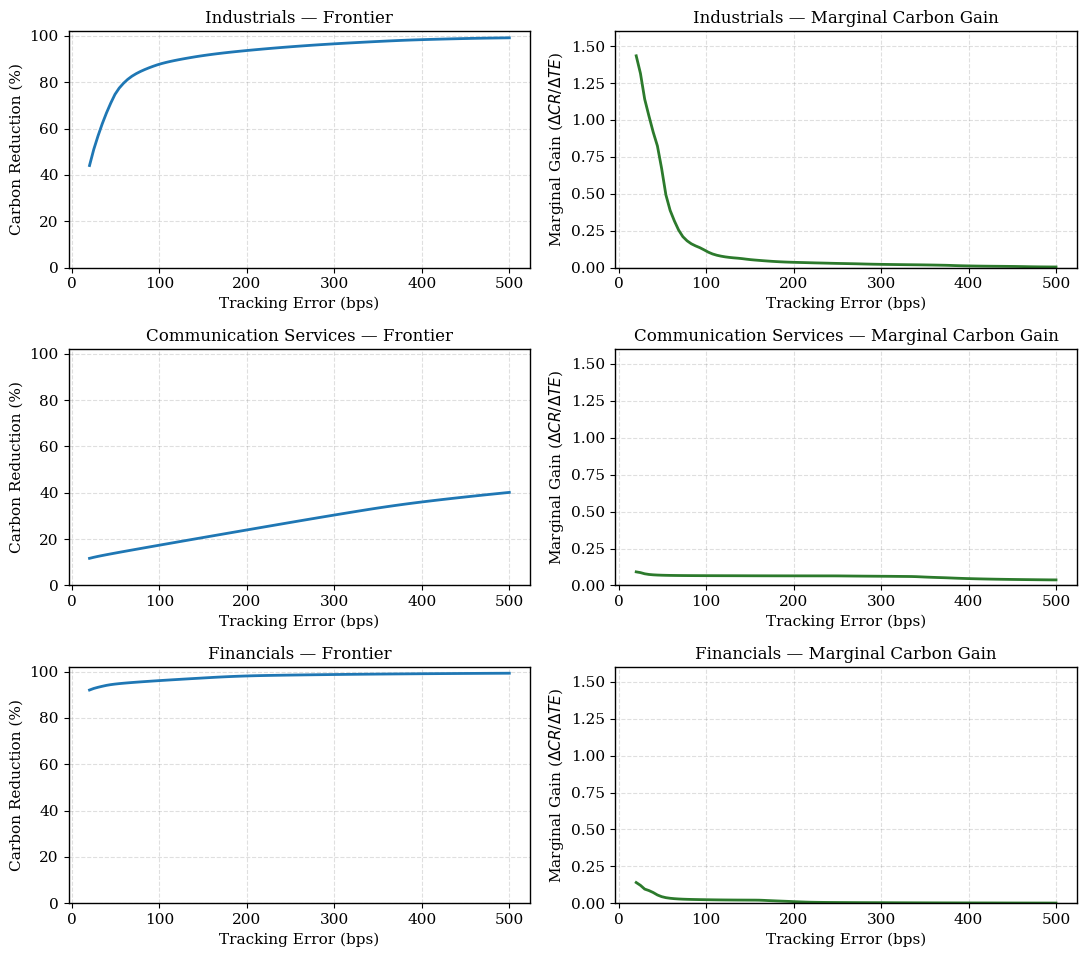

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle

# -----------------------
# GLOBAL ACADEMIC STYLE
# -----------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "gray",
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# Load latest period
last_pickle = sorted(Path("results/optimal_portfolios").glob("optimal_portfolios_all_te_*.pkl"))[-1]

with open(last_pickle, "rb") as f:
    last_period = pickle.load(f)

sectors_to_plot = ["Industrials", "Communication Services", "Financials"]

fig, axes = plt.subplots(3, 2, figsize=(11, 10))

for row, sector in enumerate(sectors_to_plot):

    data = last_period[sector]
    te = np.array(data["tracking_errors"])
    cr = np.array(data["carbon_reductions"])

    # -----------------------
    # 1) Frontier
    # -----------------------
    ax_frontier = axes[row, 0]
    ax_frontier.plot(te, cr, "-", lw=2.0, color="#1f77b4")
    ax_frontier.set_title(f"{sector} — Frontier", fontsize=12)
    ax_frontier.set_xlabel("Tracking Error (bps)")
    ax_frontier.set_ylabel("Carbon Reduction (%)")
    ax_frontier.set_ylim(0, 102)   # instead of (0, 100)

    ax_frontier.grid(True)

    # -----------------------
    # 2) Marginal gains
    # -----------------------
    marginal = np.gradient(cr, te)
    ax_marg = axes[row, 1]
    ax_marg.plot(te, marginal, "-", lw=2.0, color="#2c7a2c")
    ax_marg.axhline(0, color="black", linewidth=0.8)
    ax_marg.set_title(f"{sector} — Marginal Carbon Gain", fontsize=12)
    ax_marg.set_xlabel("Tracking Error (bps)")
    ax_marg.set_ylabel(r"Marginal Gain ($\Delta CR / \Delta TE$)")
    ax_marg.set_ylim(0, 1.6)
    ax_marg.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("results/te_carbon_marginal_gains_last_period_academic.pdf", 
            bbox_inches="tight")

plt.show()
